SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

df_inner = pd.read_csv('../bases/tabelas_unificadas/Base_Unificada_Tratada.csv')
df_outer = pd.read_csv('../bases/tabelas_unificadas/Base_Unificada_Outer.csv')

# Paleta consistente para todo o notebook
PALETTE = {0: "#4C72B0", 1: "#C44E52"}  # 0 = não-churn, 1 = churn
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

VISAO GERAL E COMPARATIVA 

In [2]:
def overview(df, nome="dataset"):
    print(f"===== {nome.upper()} =====")
    print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
    print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\nTipos de dados:\n{df.dtypes.value_counts()}")
    
    resumo = pd.DataFrame({
        "dtype": df.dtypes,
        "n_unicos": df.nunique(),
        "missing_n": df.isnull().sum(),
        "missing_%": (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values("missing_%", ascending=False)
    
    return resumo

resumo_inner = overview(df_inner, "inner merge")
resumo_outer = overview(df_outer, "outer merge")
resumo_outer  # ver colunas com mais missing

===== INNER MERGE =====
Shape: 81,881 linhas x 84 colunas
Memória: 60.24 MB

Tipos de dados:
int64      42
float64    40
str         2
Name: count, dtype: int64
===== OUTER MERGE =====
Shape: 100,000 linhas x 84 colunas
Memória: 73.38 MB

Tipos de dados:
float64    80
int64       2
str         2
Name: count, dtype: int64


,dtype,n_unicos,missing_n,missing_%
valor_premio_anual,float64,57863,11374,11.37
valor_cobertura_total,float64,88217,11241,11.24
num_apolices_ativas,float64,6,11007,11.01
num_apolices_basica,float64,7,11007,11.01
num_apolices_padrao,float64,7,11007,11.01
...,...,...,...,...
escolaridade_Medio,float64,2,1293,1.29
escolaridade_Pos,float64,2,1293,1.29
idade,float64,78,1293,1.29
cod_individuo,int64,100000,0,0.00


DECISAO ENTRE INNER OU OUTER

In [5]:
diff_linhas = len(df_outer) - len(df_inner)
pct_diff = diff_linhas / len(df_outer) * 100

print(f"Outer tem {diff_linhas:,} linhas extras em relação à inner ({pct_diff:.1f}% da base outer)")

# Quem são essas linhas extras? (assumindo uma coluna chave, ex: 'cod_individuo')
ids_so_outer = set(df_outer["cod_individuo"]) - set(df_inner["cod_individuo"])
extras = df_outer[df_outer["cod_individuo"].isin(ids_so_outer)]

print(f"\nMissing médio nessas linhas extras vs base completa:")
print(f"Linhas extras: {extras.isnull().mean().mean()*100:.1f}% missing médio")
print(f"Base outer completa: {df_outer.isnull().mean().mean()*100:.1f}% missing médio")

# Essas linhas extras têm informação de churned (target)?
print(f"\n% com target preenchido nas linhas extras: {extras['churned'].notna().mean()*100:.1f}%")

Outer tem 18,119 linhas extras em relação à inner (18.1% da base outer)

Missing médio nessas linhas extras vs base completa:
Linhas extras: 28.0% missing médio
Base outer completa: 6.1% missing médio

% com target preenchido nas linhas extras: 100.0%


ANALISES DOS VALORES NULOS

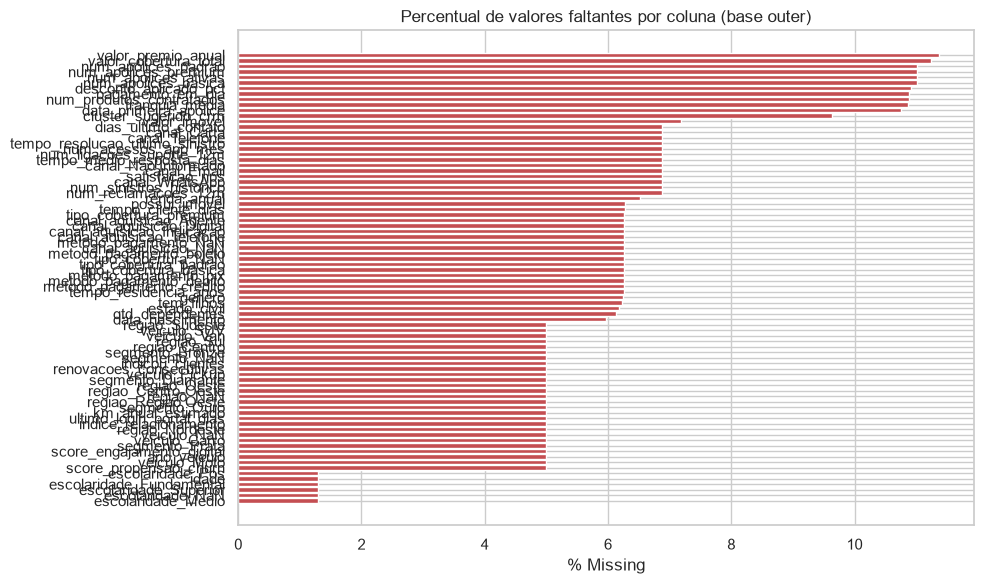

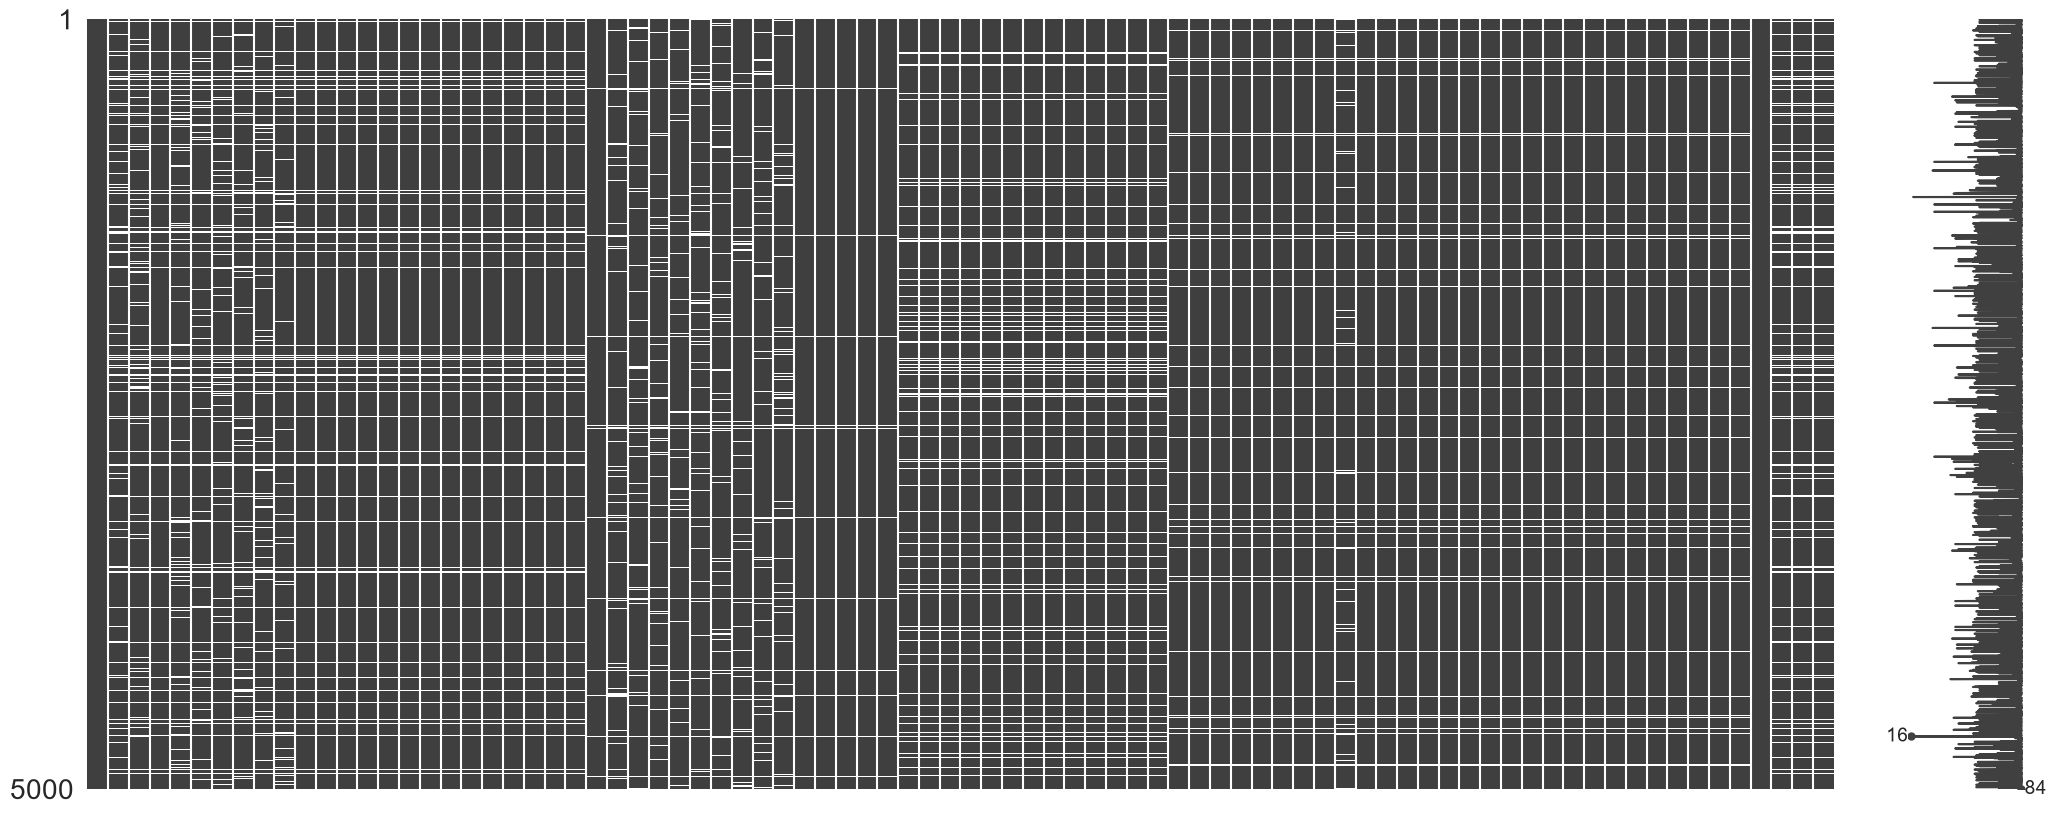

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_pct = resumo_outer["missing_%"].sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

ax.barh(missing_pct.index, missing_pct.values, color="#C44E52")
ax.set_xlabel("% Missing")
ax.set_title("Percentual de valores faltantes por coluna (base outer)")
plt.tight_layout()
plt.show()

# matriz visual rápida (amostra para performance)
msno.matrix(df_outer.sample(min(5000, len(df_outer)), random_state=42))
plt.show()

DUPLICATAS E INCONSISTÊNCIAS

In [8]:
print(f"Linhas duplicadas (todas colunas): {df_outer.duplicated().sum()}")
print(f"IDs de cliente duplicados: {df_outer['cod_individuo'].duplicated().sum()}")

# checagens de sanidade — ajuste para as colunas reais da sua base
checagens = {
    "idade_negativa": (df_outer.get("idade", pd.Series(dtype=float)) < 0).sum(),
    "idade_implausivel": (df_outer.get("idade", pd.Series(dtype=float)) > 100).sum(),
    "premio_zero_ou_negativo": (df_outer.get("premio", pd.Series(dtype=float)) <= 0).sum(),
}
pd.Series(checagens)

Linhas duplicadas (todas colunas): 0
IDs de cliente duplicados: 0


idade_negativa             0
idade_implausivel          0
premio_zero_ou_negativo    0
dtype: int64

✅ Removidas score_propensao_churn e cluster_sugerido_crm (colunas de teste, confirmado).
✅ Unificada regiao_Oeste + regiao_Regiao Oeste (inconsistência de nomenclatura na fonte).
✅ satisfacao_nps: 222 registros (0,22%) acima de 10 foram capados em 10 (ruído de escala).

In [16]:
import pandas as pd

df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Tratada.csv")  # ajuste o caminho/nome do arquivo

# Tratamentos finais identificados na EDA
df = df.drop(columns=["score_propensao_churn", "cluster_sugerido_crm"])  # colunas de teste

df["regiao_Oeste"] = df["regiao_Oeste"].fillna(0) + df["regiao_Regiao Oeste"].fillna(0)
df["regiao_Oeste"] = df["regiao_Oeste"].clip(upper=1)
df = df.drop(columns=["regiao_Regiao Oeste"])

df["satisfacao_nps"] = df["satisfacao_nps"].clip(lower=0, upper=10)  # 222 registros fora da escala 0-10

GRAFICOS

Taxa média de churn: 12.1%


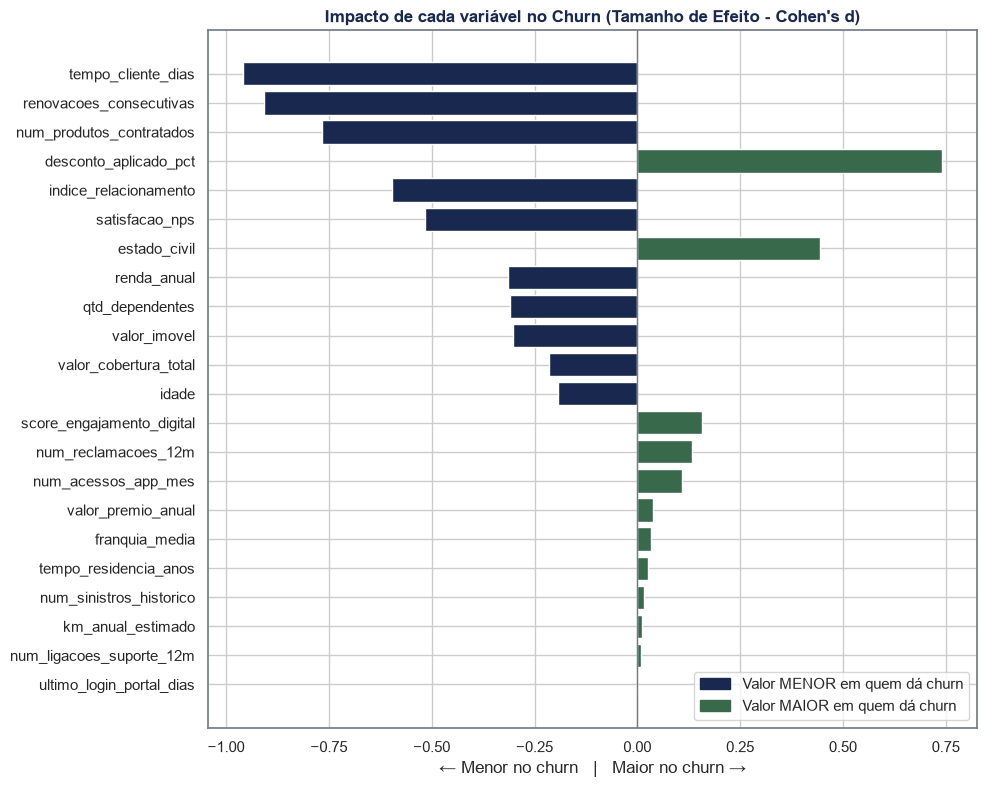

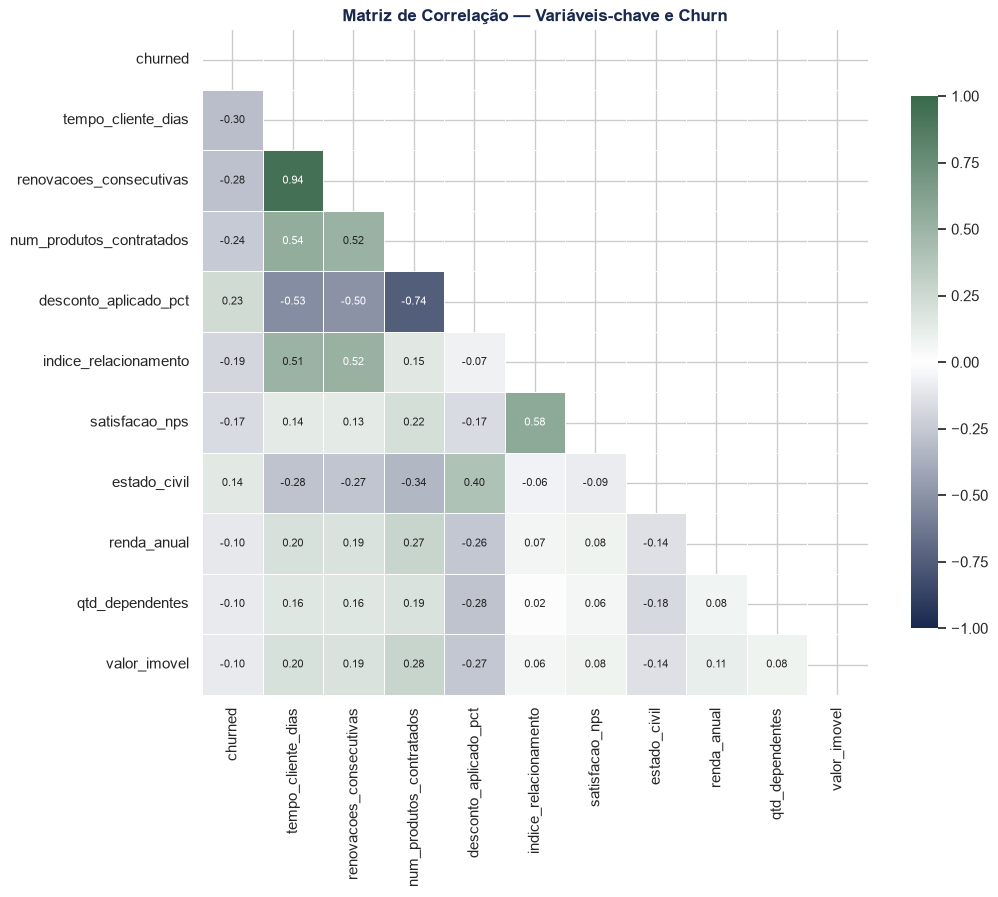

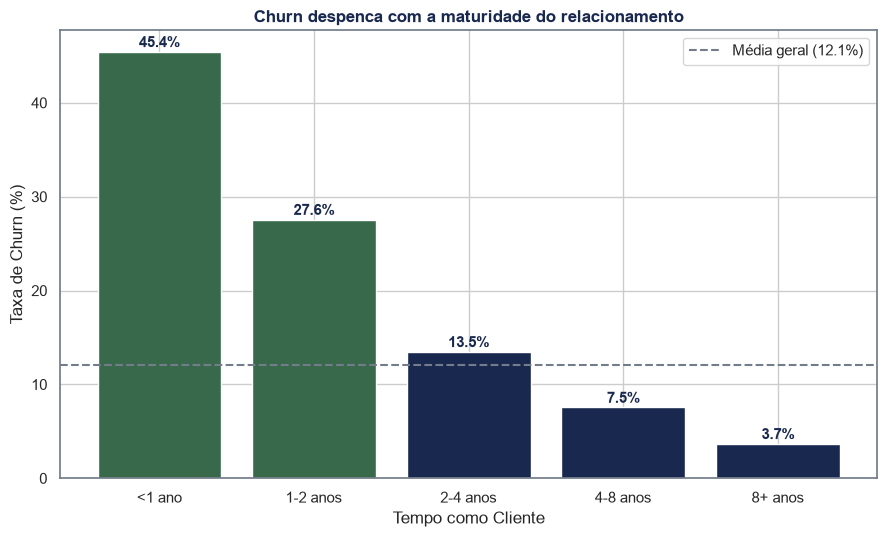

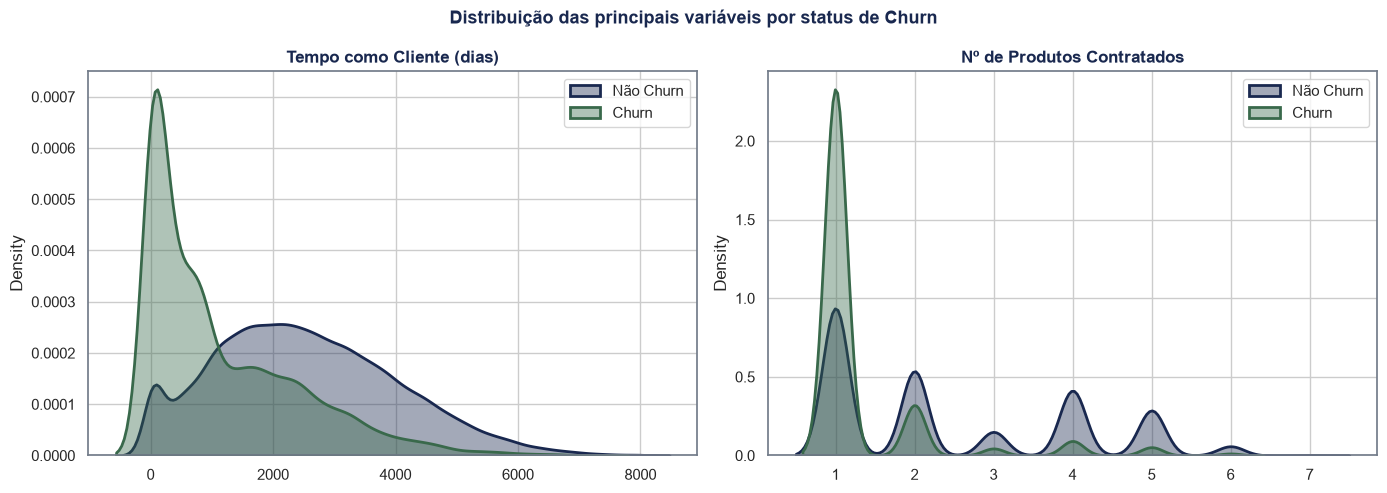

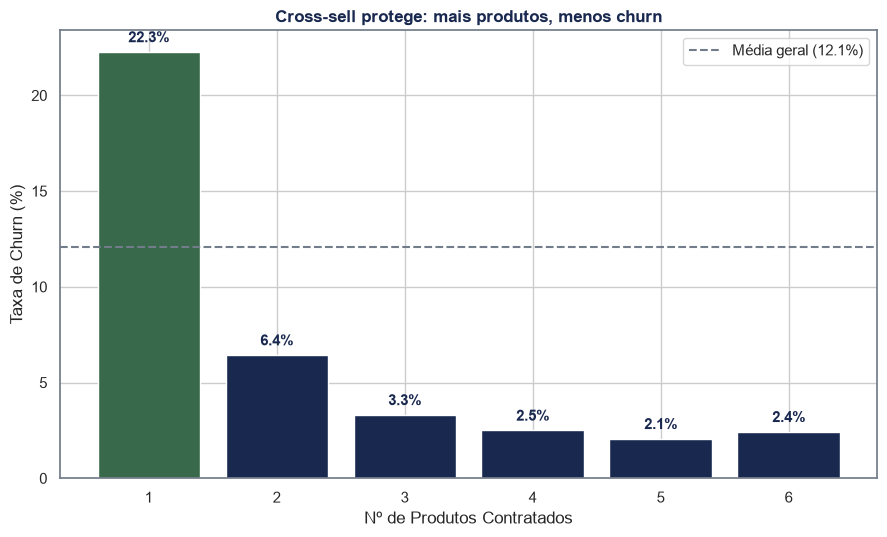

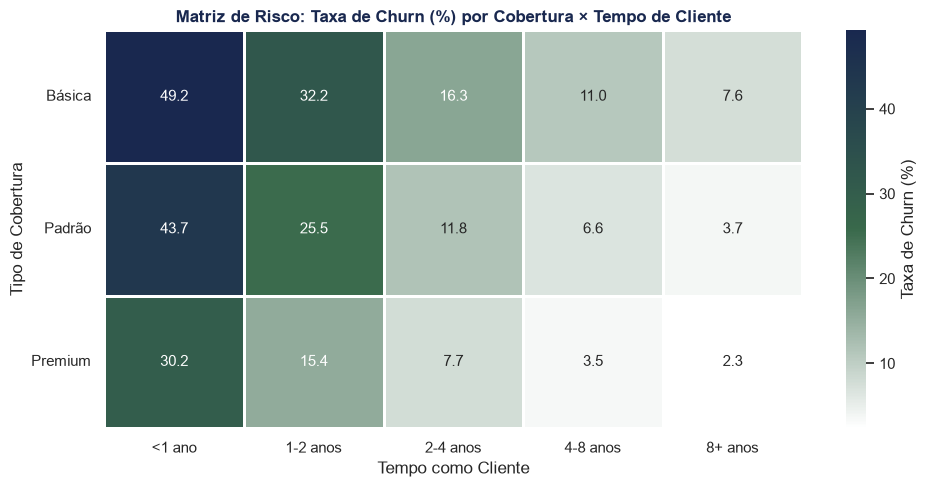

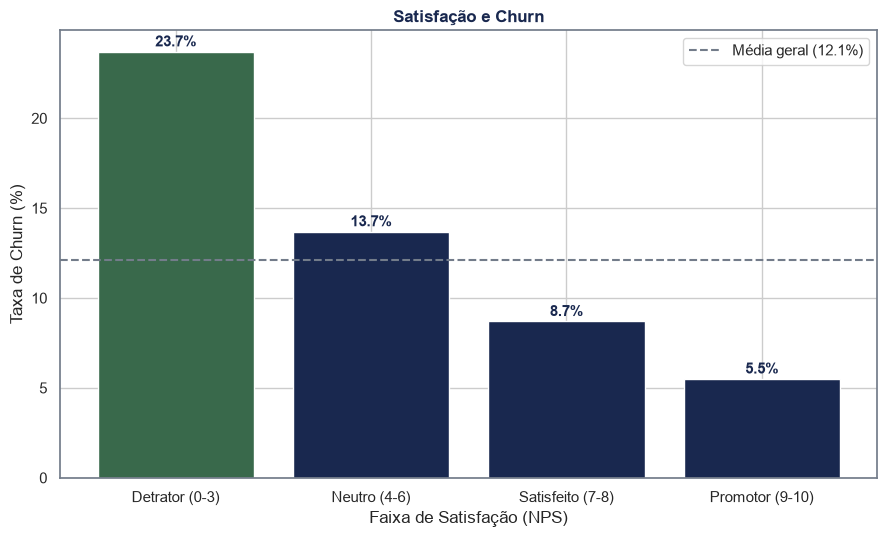

In [20]:
# =============================================================================
# EDA — PRT SEGURADORA | Gráficos Estratégicos de Churn
# Paleta oficial PRT: marinho #19284F | verde #39694B | cinza #737C8A
# =============================================================================
# Cada bloco abaixo (marcado com "# CÉLULA N") pode ser colado em uma célula
# separada do Jupyter. Assume que a base já está carregada em `df`.
# =============================================================================


# =============================================================================
# CÉLULA 0 — Imports e configuração da identidade visual PRT
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# --- Paleta oficial PRT Seguradora ---
PRT_MARINHO = "#19284F"   # cor primária  -> usada para "Não Churn"
PRT_VERDE   = "#39694B"   # cor secundária -> usada para "Churn"
PRT_CINZA   = "#737C8A"   # neutro de apoio (linhas de referência, bordas)

# Colormaps contínuos derivados da marca
PRT_DIVERGING = LinearSegmentedColormap.from_list("prt_div", [PRT_MARINHO, "#FFFFFF", PRT_VERDE])
PRT_SEQ       = LinearSegmentedColormap.from_list("prt_seq", ["#FFFFFF", PRT_VERDE, PRT_MARINHO])

# Estilo base
sns.set_theme(style="whitegrid")
mpl.rcParams["axes.edgecolor"] = PRT_CINZA
mpl.rcParams["font.size"] = 11

# Lista de variáveis numéricas usadas nas análises
NUM_COLS = [
    "valor_premio_anual", "tempo_cliente_dias", "num_produtos_contratados",
    "valor_cobertura_total", "franquia_media", "idade", "renda_anual",
    "valor_imovel", "num_reclamacoes_12m", "num_sinistros_historico",
    "satisfacao_nps", "score_engajamento_digital", "indice_relacionamento",
    "km_anual_estimado", "num_acessos_app_mes", "ultimo_login_portal_dias",
    "renovacoes_consecutivas", "num_ligacoes_suporte_12m",
    "tempo_residencia_anos", "qtd_dependentes", "desconto_aplicado_pct",
    "estado_civil",  # incluída a pedido — variável binária (0/1)
]

# Taxa média de churn (usada como linha de referência nos gráficos)
TAXA_MEDIA_CHURN = df["churned"].mean() * 100
print(f"Taxa média de churn: {TAXA_MEDIA_CHURN:.1f}%")


# =============================================================================
# CÉLULA 1 — Feature Importance via Tamanho de Efeito (Cohen's d)
# Quais variáveis mais separam quem dá churn de quem não dá.
# =============================================================================
rows = []
for col in NUM_COLS:
    g0 = df.loc[df["churned"] == 0, col].dropna()
    g1 = df.loc[df["churned"] == 1, col].dropna()
    if len(g0) < 30 or len(g1) < 30:
        continue
    # Desvio-padrão agrupado (pooled) para o cálculo do Cohen's d
    pooled_std = np.sqrt(
        ((len(g0) - 1) * g0.std()**2 + (len(g1) - 1) * g1.std()**2)
        / (len(g0) + len(g1) - 2)
    )
    d = (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0
    rows.append({"variavel": col, "cohens_d": d})

imp = pd.DataFrame(rows)
imp["abs_d"] = imp["cohens_d"].abs()
imp = imp.sort_values("abs_d", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
cores = [PRT_VERDE if v > 0 else PRT_MARINHO for v in imp["cohens_d"]]
ax.barh(imp["variavel"], imp["cohens_d"], color=cores)
ax.axvline(0, color=PRT_CINZA, lw=1)
ax.set_title("Impacto de cada variável no Churn (Tamanho de Efeito - Cohen's d)",
             fontweight="bold", color=PRT_MARINHO)
ax.set_xlabel("← Menor no churn   |   Maior no churn →")
legenda = [
    mpatches.Patch(color=PRT_MARINHO, label="Valor MENOR em quem dá churn"),
    mpatches.Patch(color=PRT_VERDE,   label="Valor MAIOR em quem dá churn"),
]
ax.legend(handles=legenda, loc="lower right", frameon=True)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 2 — Matriz de Correlação (top 10 variáveis + target)
# Relações entre variáveis e identificação de multicolinearidade.
# =============================================================================
corr_cols = ["churned"] + imp.sort_values("abs_d", ascending=False)["variavel"].head(10).tolist()
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # esconde o triângulo superior
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=PRT_DIVERGING, center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .8}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Matriz de Correlação — Variáveis-chave e Churn",
             fontweight="bold", color=PRT_MARINHO)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 3 — Taxa de Churn por Faixa de Tempo de Cliente
# =============================================================================
df["faixa_tempo"] = pd.cut(
    df["tempo_cliente_dias"],
    bins=[0, 365, 730, 1460, 2920, 10000],
    labels=["<1 ano", "1-2 anos", "2-4 anos", "4-8 anos", "8+ anos"],
)
taxa = df.groupby("faixa_tempo", observed=True)["churned"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(taxa.index.astype(str), taxa.values,
              color=[PRT_VERDE if v > 15 else PRT_MARINHO for v in taxa.values])
ax.axhline(TAXA_MEDIA_CHURN, color=PRT_CINZA, ls="--", lw=1.5,
           label=f"Média geral ({TAXA_MEDIA_CHURN:.1f}%)")
ax.set_ylabel("Taxa de Churn (%)")
ax.set_xlabel("Tempo como Cliente")
ax.set_title("Churn despenca com a maturidade do relacionamento",
             fontweight="bold", color=PRT_MARINHO)
for i, v in enumerate(taxa.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", color=PRT_MARINHO)
ax.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 4 — Distribuições (KDE) das principais variáveis por status de churn
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plots = [
    ("tempo_cliente_dias",      axes[0], "Tempo como Cliente (dias)"),
    ("num_produtos_contratados", axes[1], "Nº de Produtos Contratados"),
]
for col, ax, titulo in plots:
    for cls, cor, lab in [(0, PRT_MARINHO, "Não Churn"), (1, PRT_VERDE, "Churn")]:
        dados = df.loc[df["churned"] == cls, col].dropna()
        sns.kdeplot(dados, ax=ax, color=cor, fill=True, alpha=0.4, label=lab, lw=2)
    ax.set_title(titulo, fontweight="bold", color=PRT_MARINHO)
    ax.set_xlabel("")
    ax.legend()
plt.suptitle("Distribuição das principais variáveis por status de Churn",
             fontweight="bold", color=PRT_MARINHO, fontsize=13)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 5 — Taxa de Churn por Nº de Produtos Contratados (efeito cross-sell)
# =============================================================================
taxa_prod = df.groupby("num_produtos_contratados", observed=True)["churned"].agg(["mean", "count"])
taxa_prod = taxa_prod[taxa_prod["count"] > 50]   # ignora categorias com poucos registros
taxa_prod["mean"] *= 100

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(taxa_prod.index.astype(int).astype(str), taxa_prod["mean"],
       color=[PRT_VERDE if v > 15 else PRT_MARINHO for v in taxa_prod["mean"]])
ax.axhline(TAXA_MEDIA_CHURN, color=PRT_CINZA, ls="--", lw=1.5,
           label=f"Média geral ({TAXA_MEDIA_CHURN:.1f}%)")
ax.set_ylabel("Taxa de Churn (%)")
ax.set_xlabel("Nº de Produtos Contratados")
ax.set_title("Cross-sell protege: mais produtos, menos churn",
             fontweight="bold", color=PRT_MARINHO)
for i, v in enumerate(taxa_prod["mean"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", color=PRT_MARINHO)
ax.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 6 — Matriz de Risco: Churn (%) por Cobertura × Tempo de Cliente
# Reconstrói a categórica "cobertura" a partir das colunas dummy.
# =============================================================================
cov_cols = ["tipo_cobertura_basica", "tipo_cobertura_padrao", "tipo_cobertura_premium"]
sub = df[cov_cols].fillna(0)
mask_cob = sub.sum(axis=1) > 0
df["cobertura"] = pd.Series(np.nan, index=df.index, dtype=object)
df.loc[mask_cob, "cobertura"] = (
    sub[mask_cob].idxmax(axis=1).str.replace("tipo_cobertura_", "", regex=False)
)

pivot = df.pivot_table(index="cobertura", columns="faixa_tempo",
                       values="churned", aggfunc="mean", observed=True) * 100
pivot = pivot.reindex(["basica", "padrao", "premium"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap=PRT_SEQ, linewidths=1,
            cbar_kws={"label": "Taxa de Churn (%)"}, ax=ax)
ax.set_title("Matriz de Risco: Taxa de Churn (%) por Cobertura × Tempo de Cliente",
             fontweight="bold", color=PRT_MARINHO)
ax.set_xlabel("Tempo como Cliente")
ax.set_ylabel("Tipo de Cobertura")
ax.set_yticklabels(["Básica", "Padrão", "Premium"], rotation=0)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 7 — Taxa de Churn por Faixa de Satisfação (NPS)
# =============================================================================
df["faixa_nps"] = pd.cut(
    df["satisfacao_nps"],
    bins=[-1, 3, 6, 8, 10],
    labels=["Detrator (0-3)", "Neutro (4-6)", "Satisfeito (7-8)", "Promotor (9-10)"],
)
taxa_nps = df.groupby("faixa_nps", observed=True)["churned"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(taxa_nps.index.astype(str), taxa_nps.values,
       color=[PRT_VERDE if v > 15 else PRT_MARINHO for v in taxa_nps.values])
ax.axhline(TAXA_MEDIA_CHURN, color=PRT_CINZA, ls="--", lw=1.5,
           label=f"Média geral ({TAXA_MEDIA_CHURN:.1f}%)")
ax.set_ylabel("Taxa de Churn (%)")
ax.set_xlabel("Faixa de Satisfação (NPS)")
ax.set_title("Satisfação e Churn", fontweight="bold", color=PRT_MARINHO)
for i, v in enumerate(taxa_nps.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold", color=PRT_MARINHO)
ax.legend()
plt.tight_layout()
plt.show()

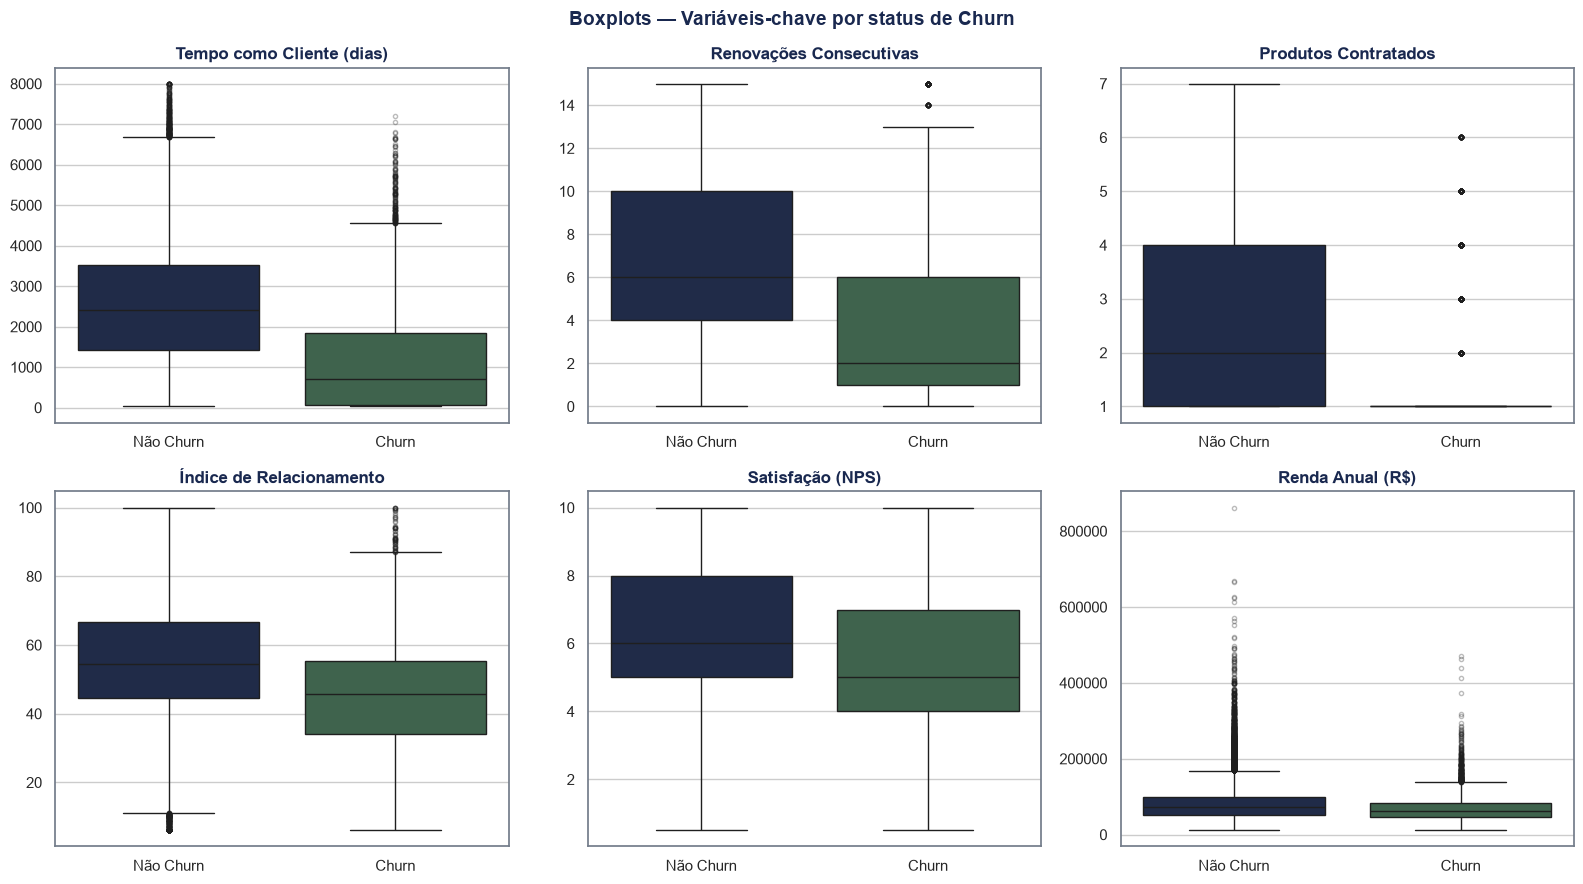

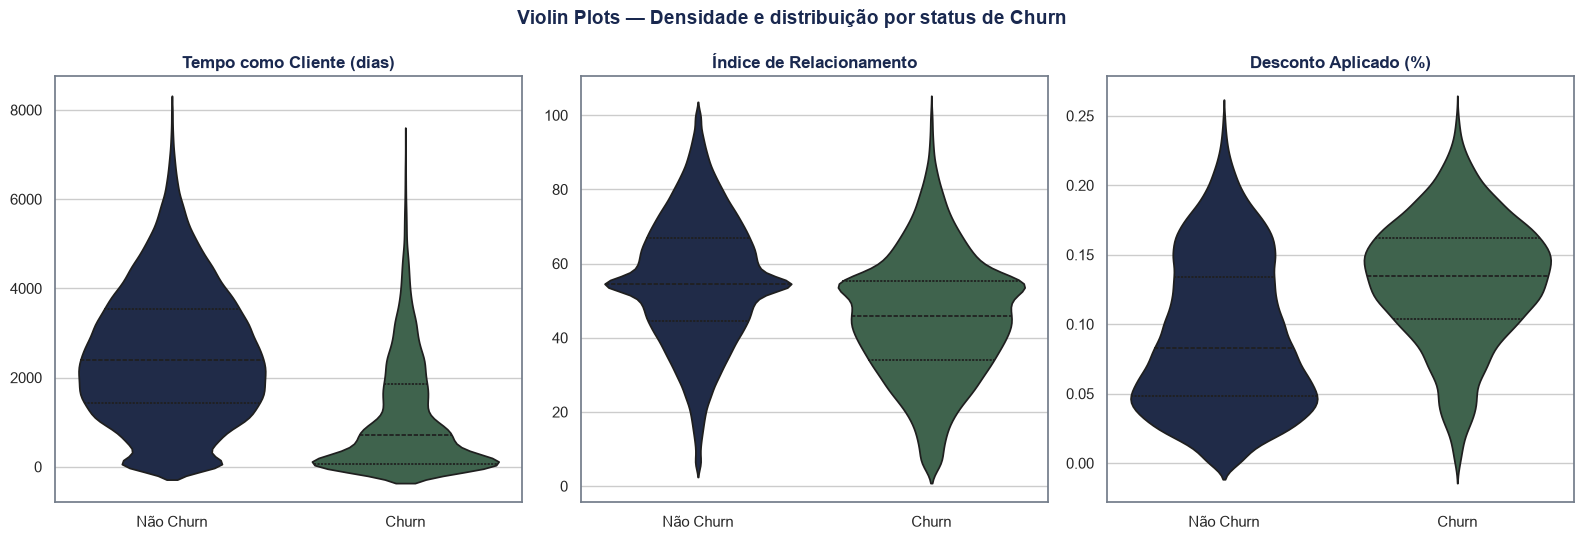

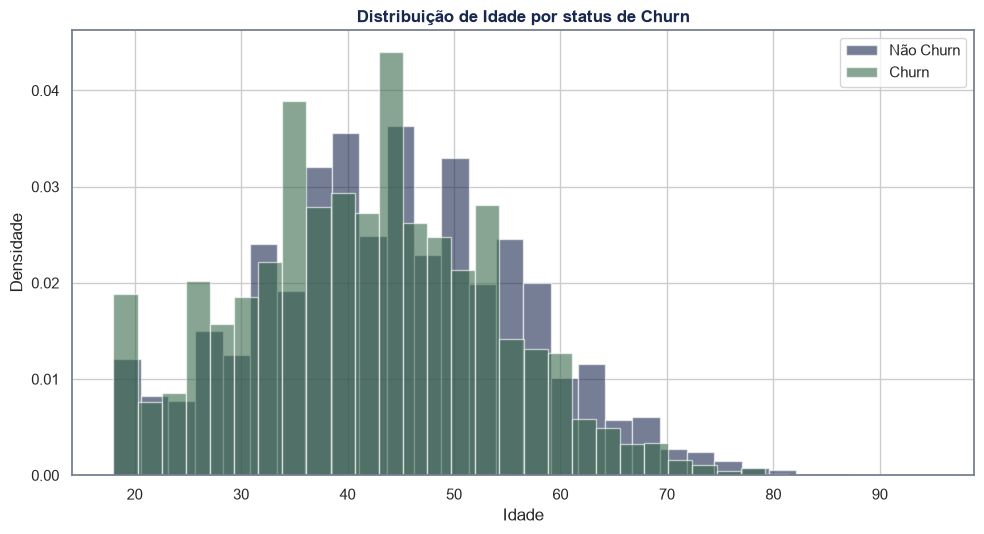

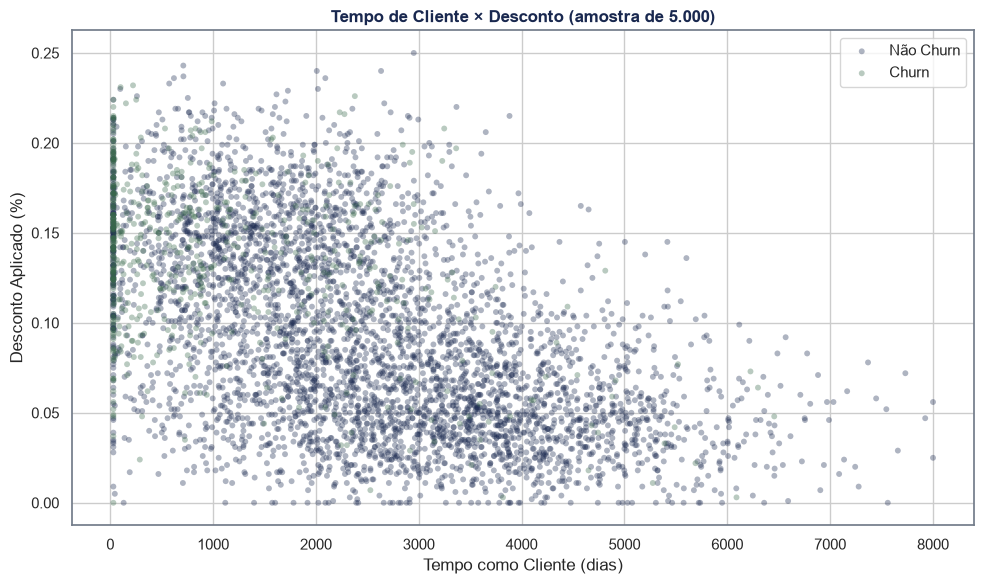

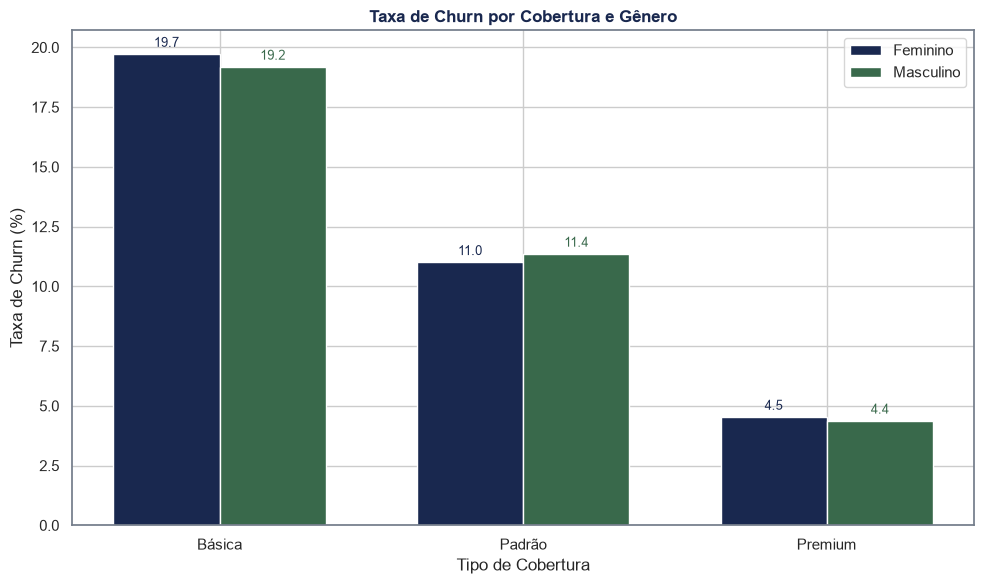

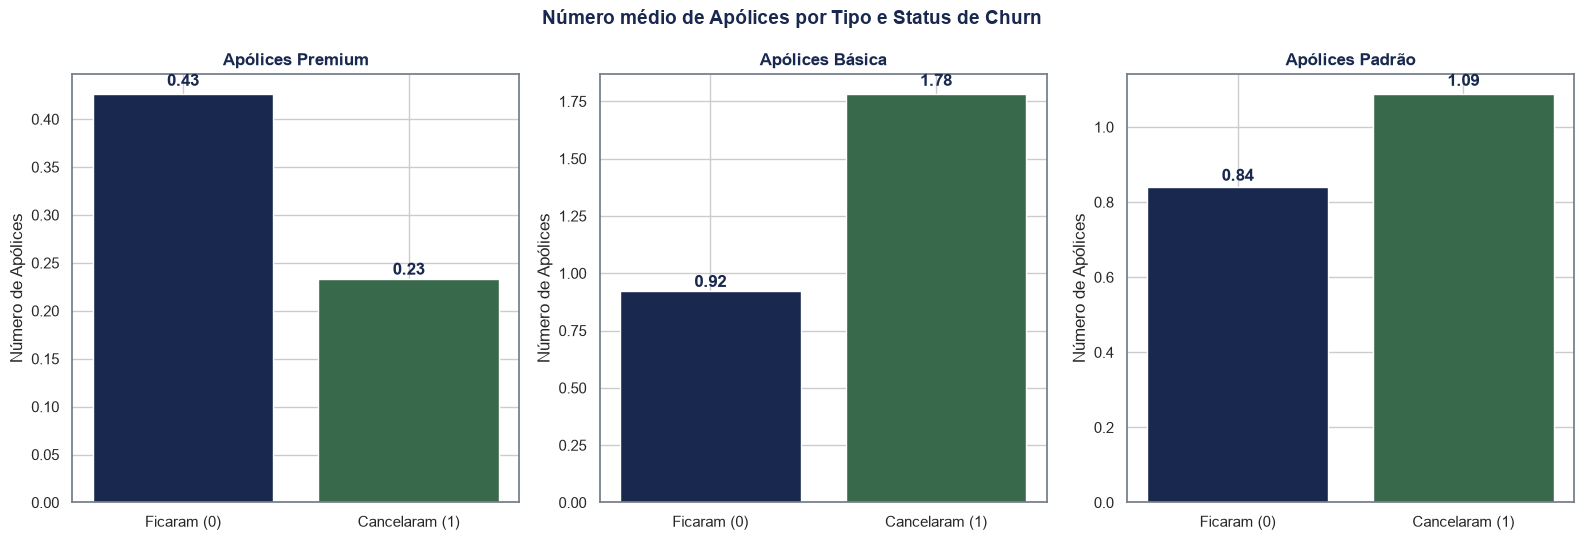

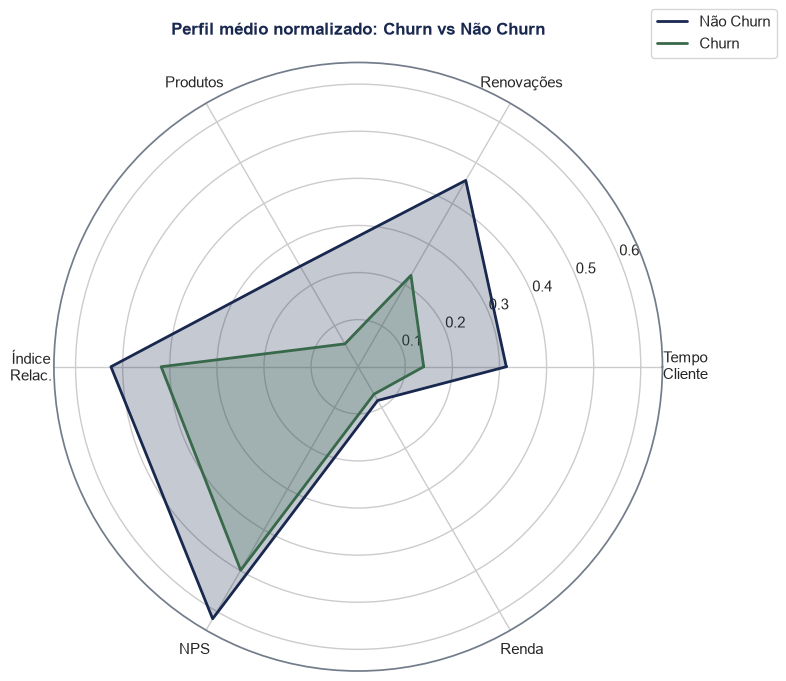

In [18]:
# =============================================================================
# EDA — PRT SEGURADORA | Gráficos Estratégicos de Churn — LOTE 2 (tipos variados)
# Boxplot, Violino, Histograma, Scatter, Barras agrupadas e Radar.
# Paleta oficial PRT: marinho #19284F | verde #39694B | cinza #737C8A
# =============================================================================
# Cole cada bloco "# CÉLULA N" em uma célula do Jupyter. Assume base em `df`.
# Requer a CÉLULA 0 do primeiro lote (paleta/imports). As constantes-chave
# estão repetidas abaixo para o lote rodar de forma independente, se preciso.
# =============================================================================


# =============================================================================
# CÉLULA 8 — Setup (repita só se não rodou o lote 1 nesta sessão)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

PRT_MARINHO = "#19284F"
PRT_VERDE   = "#39694B"
PRT_CINZA   = "#737C8A"
CHURN_PAL   = {0: PRT_MARINHO, 1: PRT_VERDE}

sns.set_theme(style="whitegrid")
mpl.rcParams["axes.edgecolor"] = PRT_CINZA

# Reconstrói a categórica "cobertura" a partir das dummies (usada adiante)
cov_cols = ["tipo_cobertura_basica", "tipo_cobertura_padrao", "tipo_cobertura_premium"]
_sub = df[cov_cols].fillna(0)
_mask = _sub.sum(axis=1) > 0
df["cobertura"] = pd.Series(np.nan, index=df.index, dtype=object)
df.loc[_mask, "cobertura"] = _sub[_mask].idxmax(axis=1).str.replace("tipo_cobertura_", "", regex=False)


# =============================================================================
# CÉLULA 9 — BOXPLOTS (grid 2x3) das variáveis-chave por status de churn
# Bom para enxergar mediana, dispersão e outliers de uma vez.
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
boxvars = [
    ("tempo_cliente_dias",       "Tempo como Cliente (dias)"),
    ("renovacoes_consecutivas",  "Renovações Consecutivas"),
    ("num_produtos_contratados", "Produtos Contratados"),
    ("indice_relacionamento",    "Índice de Relacionamento"),
    ("satisfacao_nps",           "Satisfação (NPS)"),
    ("renda_anual",              "Renda Anual (R$)"),
]
for ax, (col, tit) in zip(axes.flatten(), boxvars):
    sns.boxplot(data=df, x="churned", y=col, hue="churned", palette=CHURN_PAL,
                ax=ax, legend=False,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.3})
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Não Churn", "Churn"])
    ax.set_title(tit, fontweight="bold", color=PRT_MARINHO)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Boxplots — Variáveis-chave por status de Churn",
             fontweight="bold", color=PRT_MARINHO, fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 10 — VIOLIN PLOTS (densidade + quartis)
# Mostra o FORMATO da distribuição, não só os quartis do boxplot.
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
viovars = [
    ("tempo_cliente_dias",    "Tempo como Cliente (dias)"),
    ("indice_relacionamento", "Índice de Relacionamento"),
    ("desconto_aplicado_pct", "Desconto Aplicado (%)"),
]
for ax, (col, tit) in zip(axes, viovars):
    sns.violinplot(data=df, x="churned", y=col, hue="churned", palette=CHURN_PAL,
                   ax=ax, legend=False, inner="quartile")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Não Churn", "Churn"])
    ax.set_title(tit, fontweight="bold", color=PRT_MARINHO)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Violin Plots — Densidade e distribuição por status de Churn",
             fontweight="bold", color=PRT_MARINHO, fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 11 — HISTOGRAMA sobreposto (densidade) — Idade
# density=True normaliza as alturas, permitindo comparar grupos de tamanhos
# diferentes (lembrando que churn é só ~12% da base).
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5.5))
for cls, cor, lab in [(0, PRT_MARINHO, "Não Churn"), (1, PRT_VERDE, "Churn")]:
    ax.hist(df.loc[df["churned"] == cls, "idade"].dropna(),
            bins=30, alpha=0.6, color=cor, label=lab, density=True)
ax.set_xlabel("Idade")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição de Idade por status de Churn",
             fontweight="bold", color=PRT_MARINHO)
ax.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 12 — SCATTER (amostra) — Tempo de Cliente × Desconto
# Amostra de 5.000 pontos para performance e legibilidade (a base é grande).
# =============================================================================
amostra = df.sample(min(5000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))
for cls, cor, lab in [(0, PRT_MARINHO, "Não Churn"), (1, PRT_VERDE, "Churn")]:
    s = amostra[amostra["churned"] == cls]
    ax.scatter(s["tempo_cliente_dias"], s["desconto_aplicado_pct"],
               c=cor, label=lab, alpha=0.35, s=18, edgecolors="none")
ax.set_xlabel("Tempo como Cliente (dias)")
ax.set_ylabel("Desconto Aplicado (%)")
ax.set_title("Tempo de Cliente × Desconto (amostra de 5.000)",
             fontweight="bold", color=PRT_MARINHO)
ax.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 13 — BARRAS AGRUPADAS — Churn por Cobertura × Gênero
# Útil para testar (e descartar) gênero como fator: as barras ficam parecidas.
# =============================================================================
df["genero_lab"] = df["genero"].map({0.0: "Feminino", 1.0: "Masculino"})
tab = (df.groupby(["cobertura", "genero_lab"], observed=True)["churned"]
         .mean().mul(100).unstack())
tab = tab.reindex(["basica", "padrao", "premium"])

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(tab.index))
w = 0.35
ax.bar(x - w/2, tab["Feminino"],  w, label="Feminino",  color=PRT_MARINHO)
ax.bar(x + w/2, tab["Masculino"], w, label="Masculino", color=PRT_VERDE)
ax.set_xticks(x)
ax.set_xticklabels(["Básica", "Padrão", "Premium"])
ax.set_ylabel("Taxa de Churn (%)")
ax.set_xlabel("Tipo de Cobertura")
ax.set_title("Taxa de Churn por Cobertura e Gênero",
             fontweight="bold", color=PRT_MARINHO)
ax.legend()
for i in x:
    ax.text(i - w/2, tab["Feminino"].iloc[i] + 0.3,
            f"{tab['Feminino'].iloc[i]:.1f}", ha="center", fontsize=9, color=PRT_MARINHO)
    ax.text(i + w/2, tab["Masculino"].iloc[i] + 0.3,
            f"{tab['Masculino'].iloc[i]:.1f}", ha="center", fontsize=9, color=PRT_VERDE)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 14B — Número médio de Apólices por Tipo (Premium/Básica/Padrão) x Churn
# 3 painéis lado a lado, um por tipo de apólice.
# =============================================================================
cols_apolices = [
    ("num_apolices_premium", "Apólices Premium"),
    ("num_apolices_basica",  "Apólices Básica"),
    ("num_apolices_padrao",  "Apólices Padrão"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (col, tit) in zip(axes, cols_apolices):
    medias = df.groupby("churned")[col].mean()
    bars = ax.bar(["Ficaram (0)", "Cancelaram (1)"], medias.values,
                   color=[PRT_MARINHO, PRT_VERDE])
    ax.set_title(tit, fontweight="bold", color=PRT_MARINHO)
    ax.set_ylabel("Número de Apólices")
    for b, v in zip(bars, medias.values):
        ax.text(b.get_x() + b.get_width()/2, v + v*0.02, f"{v:.2f}",
                ha="center", fontweight="bold", color=PRT_MARINHO)

plt.suptitle("Número médio de Apólices por Tipo e Status de Churn",
             fontweight="bold", color=PRT_MARINHO, fontsize=14)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 15 — RADAR — Perfil médio normalizado: Churn vs Não Churn
# Cada eixo é normalizado 0–1 (min-max) para permitir comparar variáveis em
# escalas diferentes no mesmo gráfico.
# =============================================================================
radar_vars = ["tempo_cliente_dias", "renovacoes_consecutivas", "num_produtos_contratados",
              "indice_relacionamento", "satisfacao_nps", "renda_anual"]
labels_radar = ["Tempo\nCliente", "Renovações", "Produtos", "Índice\nRelac.", "NPS", "Renda"]

# Normalização min-max
norm = df[radar_vars].copy()
for c in radar_vars:
    norm[c] = (df[c] - df[c].min()) / (df[c].max() - df[c].min())
norm["churned"] = df["churned"]

med0 = norm[norm["churned"] == 0][radar_vars].mean().values
med1 = norm[norm["churned"] == 1][radar_vars].mean().values

angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
med0 = np.concatenate([med0, [med0[0]]])   # fecha o polígono
med1 = np.concatenate([med1, [med1[0]]])
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, med0, color=PRT_MARINHO, lw=2, label="Não Churn")
ax.fill(angles, med0, color=PRT_MARINHO, alpha=0.25)
ax.plot(angles, med1, color=PRT_VERDE, lw=2, label="Churn")
ax.fill(angles, med1, color=PRT_VERDE, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar)
ax.set_title("Perfil médio normalizado: Churn vs Não Churn",
             fontweight="bold", color=PRT_MARINHO, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

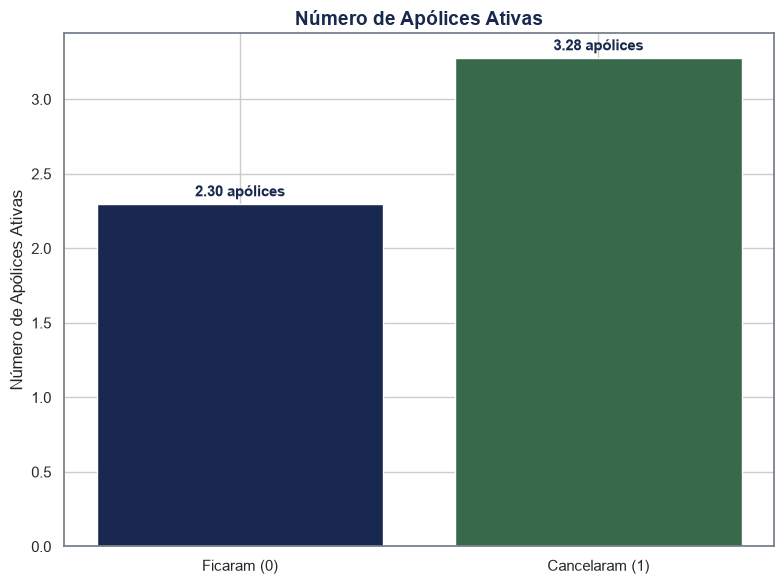

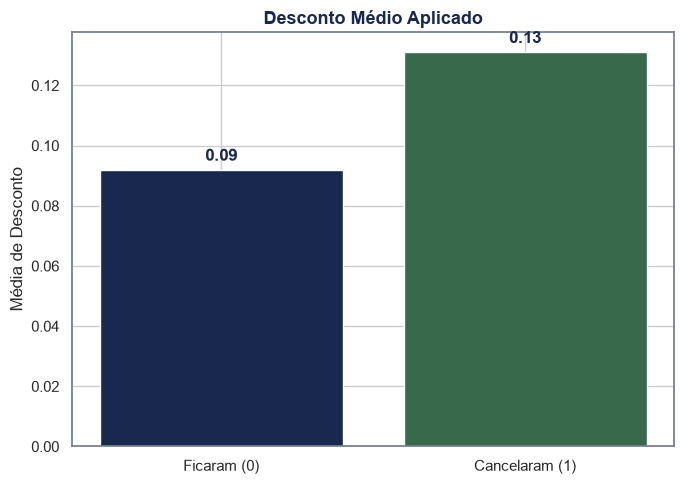

In [19]:
# =============================================================================
# CÉLULA 16 — Número de Apólices Ativas: Ficaram vs Cancelaram
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
medias = df.groupby("churned")["num_apolices_ativas"].mean()
bars = ax.bar(["Ficaram (0)", "Cancelaram (1)"], medias.values,
              color=[PRT_MARINHO, PRT_VERDE])
ax.set_title("Número de Apólices Ativas", fontweight="bold", color=PRT_MARINHO, fontsize=14)
ax.set_ylabel("Número de Apólices Ativas")
for b, v in zip(bars, medias.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f} apólices",
            ha="center", fontweight="bold", color=PRT_MARINHO, fontsize=11)
plt.tight_layout()
plt.show()


# =============================================================================
# CÉLULA 17 — Desconto Médio Aplicado: Ficaram vs Cancelaram
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 5))
medias = df.groupby("churned")["desconto_aplicado_pct"].mean()
bars = ax.bar(["Ficaram (0)", "Cancelaram (1)"], medias.values,
              color=[PRT_MARINHO, PRT_VERDE])
ax.set_title("Desconto Médio Aplicado", fontweight="bold", color=PRT_MARINHO, fontsize=13)
ax.set_ylabel("Média de Desconto")
for b, v in zip(bars, medias.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.2f}",
            ha="center", fontweight="bold", color=PRT_MARINHO)
plt.tight_layout()
plt.show()

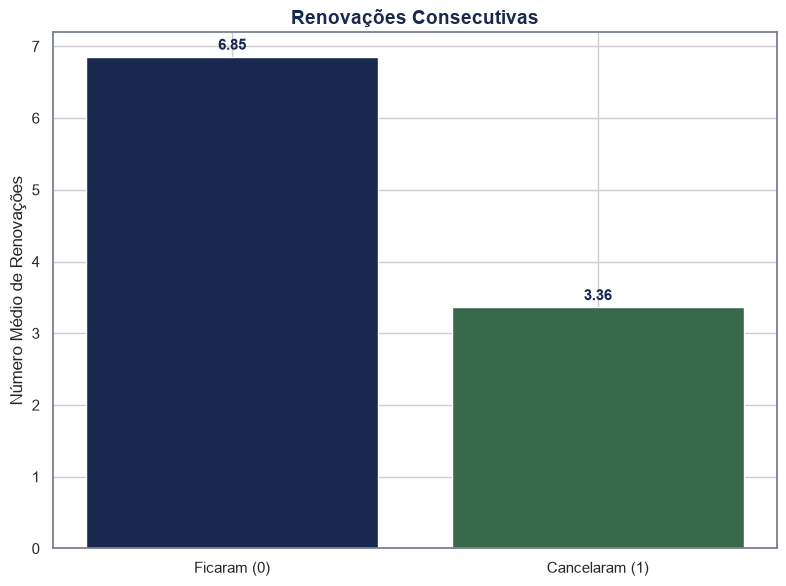

In [21]:
# =============================================================================
# CÉLULA 19 — Renovações Consecutivas: Ficaram vs Cancelaram
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
medias = df.groupby("churned")["renovacoes_consecutivas"].mean()
bars = ax.bar(["Ficaram (0)", "Cancelaram (1)"], medias.values,
              color=[PRT_MARINHO, PRT_VERDE])
ax.set_title("Renovações Consecutivas", fontweight="bold", color=PRT_MARINHO, fontsize=14)
ax.set_ylabel("Número Médio de Renovações")
for b, v in zip(bars, medias.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.1, f"{v:.2f}",
            ha="center", fontweight="bold", color=PRT_MARINHO, fontsize=11)
plt.tight_layout()
plt.show()

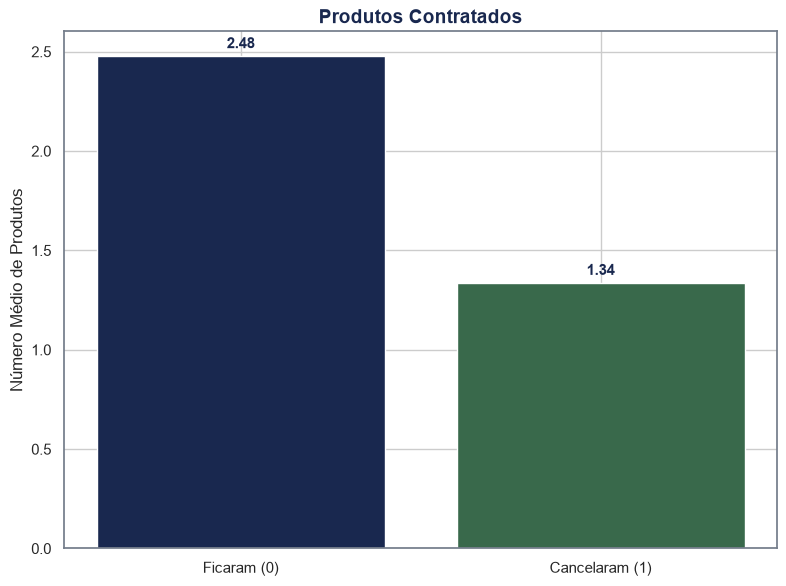

In [22]:
# =============================================================================
# CÉLULA 20 — Produtos Contratados: Ficaram vs Cancelaram
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
medias = df.groupby("churned")["num_produtos_contratados"].mean()
bars = ax.bar(["Ficaram (0)", "Cancelaram (1)"], medias.values,
              color=[PRT_MARINHO, PRT_VERDE])
ax.set_title("Produtos Contratados", fontweight="bold", color=PRT_MARINHO, fontsize=14)
ax.set_ylabel("Número Médio de Produtos")
for b, v in zip(bars, medias.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.04, f"{v:.2f}",
            ha="center", fontweight="bold", color=PRT_MARINHO, fontsize=11)
plt.tight_layout()
plt.show()